# Random Forest From Scratch (Iris Dataset)

A **Random Forest** is an ensemble of many Decision Trees. Each tree is trained on a
slightly different random subset of the data (and considers only a random subset of
features at each split). To make a final prediction, every tree "votes" for a class,
and the forest goes with the **majority vote**.

**Why does this work better than a single tree?** A single Decision Tree can easily
overfit or be thrown off by a few unusual rows in the training data (it has *high
variance*). But if you build many trees that each see the data a little differently,
their individual mistakes tend to be different too — so when you average/vote across
all of them, the mistakes cancel out and the errors that are common to the data (the
real signal) remain. This is the classic "wisdom of the crowd" effect.

The animation below shows 5 small trees, each trained on its own random sample of the
real Iris data, each casting a vote for the same test point — and the forest combining
those votes into one final prediction.

![Random Forest Animation](GIF/random_forest.gif)


## 1. Load and Explore the Data

In [23]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split

df = pd.read_csv("datasets/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


**About the dataset:** The Iris dataset has 150 rows. The input features are the
four numeric measurements `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, and
`PetalWidthCm` (all in centimeters). The target variable is `Species`, which is
**multi-class** with three possible values: `Iris-setosa`, `Iris-versicolor`, and
`Iris-virginica`. There are no missing values, and the `Id` column is just a row
identifier that we won't use as a feature.

## 2. Select Features and Target

We drop the `Id` column (it's not a real feature) and use the four measurement columns
as inputs, with `Species` as the target. Just like a single Decision Tree, a Random
Forest splits data based on thresholds, so it **does not require feature scaling**
(no need to standardize or normalize the columns).

In [24]:
feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
target_col = "Species"

X = df[feature_cols].to_numpy()
y = df[target_col].to_numpy()

print("X shape:", X.shape)
print("Classes:", np.unique(y))

X shape: (150, 4)
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


## 3. Train/Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 120
Test size: 30


## 4. The Idea Behind Random Forest

**Recap — a single Decision Tree:** at each node, the tree tries every possible
threshold on every feature and picks the split that produces the "purest" child
nodes, measured with **Gini impurity** (lower is purer). A single tree trained this
way can be sensitive to small changes in the training data — a few different rows
can lead to a very different tree (this is called *high variance*).

Random Forests fix this with two tricks:

- **Bootstrap Sampling (Bagging):** each tree is trained on a random sample of the
  training rows, drawn *with replacement* and the same size as the original training
  set. Some rows appear multiple times, others don't appear at all — so every tree
  sees a slightly different dataset.
- **Random Feature Selection:** at every split, instead of considering *all* features,
  each tree only considers a random subset of them. This forces the trees to find
  different patterns, making them more different from one another.
- **Majority Voting:** to predict a new sample, every tree predicts a class, and the
  forest returns whichever class got the most votes.

Because bagging + random features make the trees more diverse, their individual
errors are less correlated — so combining them (voting) usually generalizes better
than trusting a single tree.

## 5. Decision Tree Building Block (From Scratch)

A compact Decision Tree implementation. The only difference from a regular Decision
Tree is in `best_split`: it only searches over a **random subset of features** at
each node (`max_features`) — this is exactly what turns a Decision Tree into a
building block for a Random Forest.

In [26]:
def gini(labels):
    """Gini impurity of a list/array of class labels."""
    counts = Counter(labels)
    n = len(labels)
    return 1 - sum((count / n) ** 2 for count in counts.values())


def best_split(X, y, max_features):
    """Find the best (feature, threshold) split using Gini impurity,
    searching only over a random subset of features (size = max_features)."""
    n_samples, n_features = X.shape
    features = np.random.choice(n_features, max_features, replace=False)

    best_gini, best_feat, best_thresh = None, None, None
    for feat in features:
        thresholds = np.unique(X[:, feat])
        for t in thresholds:
            left_mask = X[:, feat] <= t
            right_mask = ~left_mask
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue
            g_left = gini(y[left_mask])
            g_right = gini(y[right_mask])
            weighted_gini = (left_mask.sum() * g_left + right_mask.sum() * g_right) / n_samples
            if best_gini is None or weighted_gini < best_gini:
                best_gini, best_feat, best_thresh = weighted_gini, feat, t

    return best_feat, best_thresh


def build_tree(X, y, max_depth, max_features, depth=0):
    """Recursively build a tree. Stops on a pure node, too few samples,
    or when max_depth is reached."""
    if len(set(y)) == 1 or len(y) < 2 or depth == max_depth:
        return {"leaf": True, "class": Counter(y).most_common(1)[0][0]}

    feat, thresh = best_split(X, y, max_features)
    if feat is None:
        return {"leaf": True, "class": Counter(y).most_common(1)[0][0]}

    left_mask = X[:, feat] <= thresh
    right_mask = ~left_mask

    return {
        "leaf": False,
        "feature": feat,
        "threshold": thresh,
        "left": build_tree(X[left_mask], y[left_mask], max_depth, max_features, depth + 1),
        "right": build_tree(X[right_mask], y[right_mask], max_depth, max_features, depth + 1),
    }


def predict_one_tree(node, x):
    """Walk a single sample down the tree to a leaf and return its class."""
    while not node["leaf"]:
        node = node["left"] if x[node["feature"]] <= node["threshold"] else node["right"]
    return node["class"]

## 6. Random Forest From Scratch

Now the actual ensemble logic: build many trees (each on its own bootstrap sample,
each using random feature selection), then combine their predictions by majority vote.

In [27]:
def bootstrap_sample(X, y):
    """Draw a random sample of rows, the same size as the data, with replacement."""
    n_samples = X.shape[0]
    idx = np.random.randint(0, n_samples, n_samples)
    return X[idx], y[idx]


def build_forest(X, y, n_trees=10, max_depth=4, max_features=None):
    """Train a Random Forest: a list of Decision Trees, each grown on a
    bootstrap sample using random feature selection at every split."""
    if max_features is None:
        max_features = int(np.sqrt(X.shape[1]))  # common default rule of thumb

    forest = []
    for _ in range(n_trees):
        X_sample, y_sample = bootstrap_sample(X, y)          # bagging
        tree = build_tree(X_sample, y_sample, max_depth, max_features)  # random features inside
        forest.append(tree)
    return forest


def predict_forest(forest, X):
    """Predict a class for every row in X by majority vote across all trees."""
    predictions = []
    for x in X:
        votes = [predict_one_tree(tree, x) for tree in forest]
        majority_class = Counter(votes).most_common(1)[0][0]
        predictions.append(majority_class)
    return np.array(predictions)

## 7. Training the Model

We grow 15 trees. During training, each tree sees a different bootstrap sample of the
training rows and, at every split, only considers a random subset of the features — so
every tree ends up "looking" at the data slightly differently.

In [28]:
np.random.seed(42)
forest = build_forest(X_train, y_train, n_trees=15, max_depth=4)
print(f"Trained a forest of {len(forest)} trees.")

Trained a forest of 15 trees.


## 8. Making Predictions

In [29]:
y_pred = predict_forest(forest, X_test)
y_pred[:10]

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor'], dtype='<U15')

## 9. Model Evaluation

We compute accuracy manually, and also compare against a **single** Decision Tree
trained the same way (one bootstrap sample, random feature selection) to see the
benefit of the ensemble.

In [30]:
accuracy = np.mean(y_pred == y_test)
print(f"Random Forest accuracy: {accuracy:.3f}")

Random Forest accuracy: 1.000


In [31]:
# 3x3 confusion matrix, built manually
classes = np.unique(y)
conf_matrix = np.zeros((len(classes), len(classes)), dtype=int)

for true_label, pred_label in zip(y_test, y_pred):
    i = np.where(classes == true_label)[0][0]
    j = np.where(classes == pred_label)[0][0]
    conf_matrix[i, j] += 1

print("Rows = true class, Columns = predicted class")
pd.DataFrame(conf_matrix, index=classes, columns=classes)

Rows = true class, Columns = predicted class


,Iris-setosa,Iris-versicolor,Iris-virginica
Iris-setosa,10,0,0
Iris-versicolor,0,9,0
Iris-virginica,0,0,11


In [32]:
# Compare to a single Decision Tree (one bootstrap sample, random features)
np.random.seed(42)
X_sample, y_sample = bootstrap_sample(X_train, y_train)
single_tree = build_tree(X_sample, y_sample, max_depth=4, max_features=int(np.sqrt(X.shape[1])))
y_pred_single = np.array([predict_one_tree(single_tree, x) for x in X_test])
single_tree_accuracy = np.mean(y_pred_single == y_test)

print(f"Single Decision Tree accuracy: {single_tree_accuracy:.3f}")
print(f"Random Forest accuracy:        {accuracy:.3f}")

Single Decision Tree accuracy: 0.967
Random Forest accuracy:        1.000


## 10. Visualization

Iris has 4 features, so we can't plot everything at once. We'll use the two most
informative ones — **Petal Length** and **Petal Width** — and plot the data colored
by class, overlaid with the decision regions of a forest retrained using just these
two features.

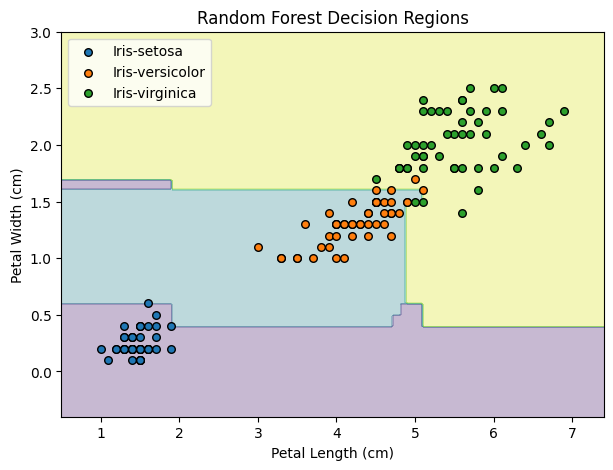

In [33]:
import matplotlib.pyplot as plt

# Retrain a small forest using only Petal Length & Petal Width, for plotting
plot_features = ["PetalLengthCm", "PetalWidthCm"]
X_plot = df[plot_features].to_numpy()
y_plot = df[target_col].to_numpy()

np.random.seed(42)
X_plot_train, X_plot_test, y_plot_train, y_plot_test = train_test_split(
    X_plot, y_plot, test_size=0.2, random_state=42
)
plot_forest = build_forest(X_plot_train, y_plot_train, n_trees=15, max_depth=4)

# Build a grid covering the feature space
x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

grid_preds = predict_forest(plot_forest, grid_points)
class_to_num = {c: i for i, c in enumerate(classes)}
Z = np.array([class_to_num[p] for p in grid_preds]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
for c in classes:
    mask = y_plot == c
    plt.scatter(X_plot[mask, 0], X_plot[mask, 1], label=c, edgecolor="k", s=30)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Random Forest Decision Regions")
plt.legend()
plt.show()

## 11. Conclusion

A **Random Forest** is a collection of Decision Trees whose predictions are combined
by majority vote. Two tricks make the trees diverse enough to be worth combining:
**bootstrap sampling** (each tree trains on a random, with-replacement sample of the
rows) and **random feature selection** (each split only considers a random subset of
features). Because the trees are trained differently, their mistakes tend to be
different too — so voting across many trees "averages out" those mistakes, which is
usually more accurate and more stable than relying on a single Decision Tree.